# 04_ml_forecasting
Forecast monthly Sales and Profit from the feature-engineered dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv("../data/cleaned/superstore_features.csv")
df["Order_Date"] = pd.to_datetime(df["Order_Date"])


In [3]:
monthly=(df.groupby(pd.Grouper(key="Order_Date",freq="ME"))
           .agg(Sales=("Sales","sum"),
                Profit=("Profit","sum"),
                Orders=("Order_ID","nunique"),
                Quantity=("Quantity","sum"),
                Discount=("Discount","mean"),
                Shipping_Cost=("Shipping_Cost","mean"))
           .reset_index())

monthly["Month_Number"]=range(len(monthly))
display(monthly.head())


,Order_Date,Sales,Profit,Orders,Quantity,Discount,Shipping_Cost,Month_Number
0,2011-01-31,98902,8321.80096,216,1463,0.158794,24.352859,0
1,2011-02-28,91152,12417.90698,183,1224,0.138233,28.257045,1
2,2011-03-31,145726,15303.56826,277,1836,0.137685,24.297190,2
3,2011-04-30,116927,12902.32438,267,2020,0.143230,22.969007,3
4,2011-05-31,146762,12183.82870,295,2013,0.145551,29.051601,4


In [4]:
split=int(len(monthly)*0.8)
train=monthly.iloc[:split]
test=monthly.iloc[split:]

features=["Month_Number","Orders","Quantity","Discount","Shipping_Cost"]

X_train=train[features]
X_test=test[features]

sales_model=RandomForestRegressor(n_estimators=300,random_state=42)
sales_model.fit(X_train,train["Sales"])
sales_pred=sales_model.predict(X_test)

profit_model=RandomForestRegressor(n_estimators=300,random_state=42)
profit_model.fit(X_train,train["Profit"])
profit_pred=profit_model.predict(X_test)

print("Sales MAE:",mean_absolute_error(test["Sales"],sales_pred))
print("Sales RMSE:",np.sqrt(mean_squared_error(test["Sales"],sales_pred)))
print("Profit MAE:",mean_absolute_error(test["Profit"],profit_pred))
print("Profit RMSE:",np.sqrt(mean_squared_error(test["Profit"],profit_pred)))


Sales MAE: 55612.46733333332
Sales RMSE: 75799.01366570662
Profit MAE: 8414.983438479947
Profit RMSE: 10724.301979320095


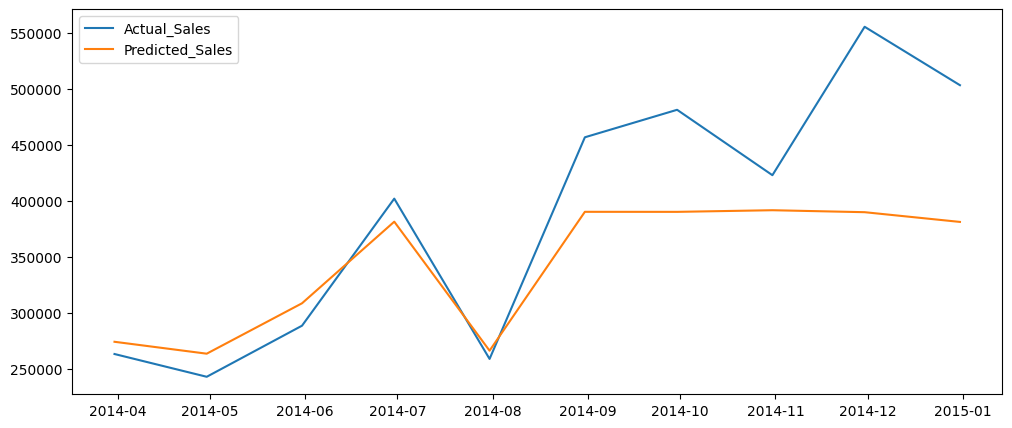

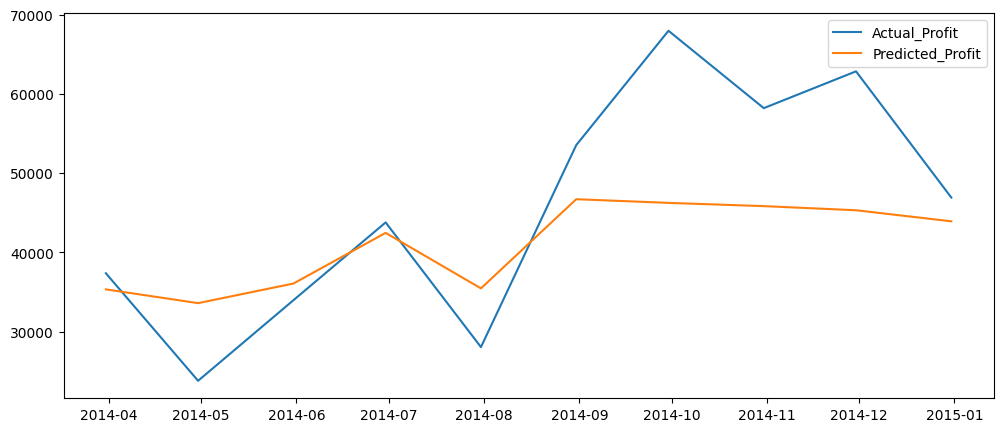

In [5]:
plt.figure(figsize=(12,5))
plt.plot(test["Order_Date"],test["Sales"],label="Actual_Sales")
plt.plot(test["Order_Date"],sales_pred,label="Predicted_Sales")
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(test["Order_Date"],test["Profit"],label="Actual_Profit")
plt.plot(test["Order_Date"],profit_pred,label="Predicted_Profit")
plt.legend()
plt.show()


In [7]:
future=monthly.tail(1).copy()
rows=[]
for _ in range(6):
    future["Month_Number"]+=1
    future["Order_Date"]=future["Order_Date"]+pd.offsets.MonthEnd()
    rows.append({
        "Order_Date":future["Order_Date"].iloc[0],
        "Forecast_Sales":sales_model.predict(future[features])[0],
        "Forecast_Profit":profit_model.predict(future[features])[0]
    })
forecast=pd.DataFrame(rows)
display(forecast)
forecast.to_csv("../data/processed/sales_profit_forecast.csv",index=False)


,Order_Date,Forecast_Sales,Forecast_Profit
0,2015-01-31,381063.003333,43919.581579
1,2015-02-28,381063.003333,43919.581579
2,2015-03-31,381063.003333,43919.581579
3,2015-04-30,381063.003333,43919.581579
4,2015-05-31,381063.003333,43919.581579
5,2015-06-30,381063.003333,43919.581579
